# Model Evaluation and Validation

## Learning Objectives
- Learn about train/test split and cross-validation.
- Understand evaluation metrics for classification and regression.

## Introduction
Model evaluation ensures that AI models generalize well to new data. Proper validation techniques and metrics help avoid overfitting.

## Core Concepts

- Train/Test Split: This is the most basic method for model evaluation. The dataset is split into two parts: a training set, which is used to teach the model, and a testing set, which is held back. After the model is trained, it is used to make predictions on the test set. This provides an unbiased estimate of how the model will perform on new, unseen data.

- Cross-Validation: This is a more robust evaluation technique, especially for smaller datasets. In k-fold cross-validation, the data is divided into 'k' subsets (folds). The model is then trained 'k' times, with each run using a different fold as the test set and the remaining folds as the training set. The final performance is the average of the results from all 'k' runs, which gives a more reliable estimate of the model's generalization ability.

- Classification Metrics:
    - Accuracy: The percentage of predictions the model got right. It's simple but can be misleading if the classes are imbalanced.
    - Precision: Measures the accuracy of positive predictions. (Of all the times the model said "spam," how often was it actually spam?).
    - Recall: Measures how well the model finds all the actual positive cases. (Of all the actual spam emails, how many did the model correctly identify?).
    - F1-Score: The harmonic mean of precision and recall, providing a single score that balances both. It's useful when the cost of false positives and false negatives are both important.
    - ROC-AUC: The Area Under the ROC Curve. It measures the model's ability to distinguish between the positive and negative classes across all possible thresholds. A score of 1.0 is a perfect classifier, while 0.5 is no better than random chance.

- Regression Metrics:
    - Mean Squared Error (MSE): The average of the squared differences between the predicted and actual values. It heavily penalizes large errors.
    - Mean Absolute Error (MAE): The average of the absolute differences between predicted and actual values. It's easier to interpret than MSE because it's in the same units as the target variable.
    - R-squared (R²): The coefficient of determination. It represents the proportion of the variance in the target variable that is explained by the model. A value of 1 means the model perfectly explains the data, while a value of 0 means it explains none of the variability.


Training with classification metrics

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Accuracy: 1.00
------------------------------
Cohen's Kappa: 1.00
Matthews Correlation Coefficient: 1.00
------------------------------
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
------------------------------


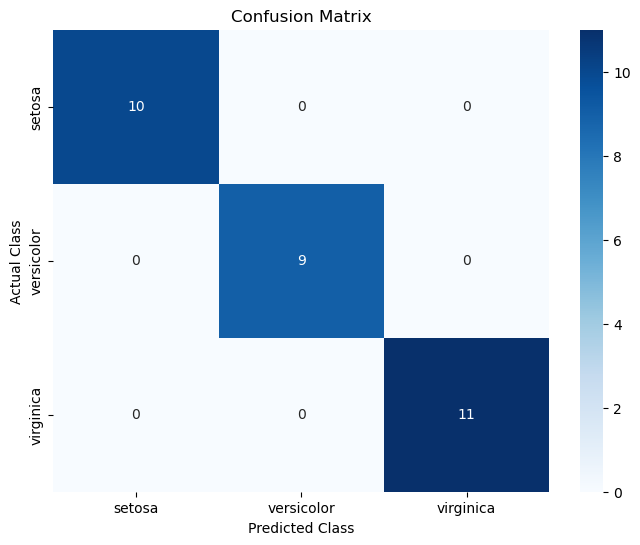


Cross-Validation
Cross-validation accuracy scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean CV Accuracy: 0.95
Std Dev CV Accuracy: 0.03
------------------------------


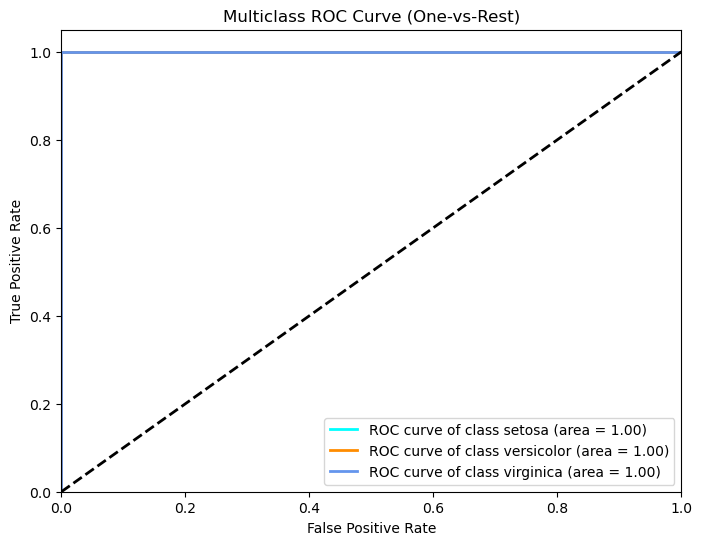

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load and split the data
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names
n_classes = len(class_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 3. Make predictions
y_pred = model.predict(X_test)
# Get prediction probabilities for each class, needed for ROC curve
y_prob = model.predict_proba(X_test) 

# --- CLASSIFICATION METRICS ---

# 4. Classification Report (from your original code)
# Provides precision, recall, and F1-score for each class.
print("="*30)
print("Classification Report")
print("="*30)
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Overall Accuracy
# The fraction of predictions our model got right.
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2f}")
print("-" * 30)

# 6. Cohen's Kappa and Matthews Correlation Coefficient (MCC)
# These are robust metrics that measure the quality of predictions,
# accounting for how a random-chance classifier would perform.
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print("-" * 30)

# 7. Confusion Matrix
# Shows the number of correct and incorrect predictions for each class.
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("-" * 30)

# Visualize the Confusion Matrix for better interpretation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# 8. Cross-Validation (from your original code)
# Evaluates model performance on different subsets of the data to ensure generalization.
print("\n" + "="*30)
print("Cross-Validation")
print("="*30)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean CV Accuracy: {scores.mean():.2f}")
print(f"Std Dev CV Accuracy: {scores.std():.2f}")
print("-" * 30)

# 9. ROC Curve and AUC for Multiclass classification
# An ROC curve plots the true positive rate against the false positive rate.
# The area under the curve (AUC) is a measure of the model's ability to distinguish between classes.
# For multiclass, we plot one curve for each class vs. the rest (One-vs-Rest).

# Binarize the output labels for the One-vs-Rest (OvR) strategy
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves on one graph
plt.figure(figsize=(8, 6))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Dashed line for random chance classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

Regression metrics

/Users/johnmoses/miniforge3/envs/mforge312/lib/python3.12/site-packages/sklearn/datasets/_base.py:1485: UserWarning: SHA256 checksum of existing local file cal_housing.tgz (f07c17ac3ca9fc1856beb372003bda47a23cf62f68f74fdb5238c45fcc361dcf) differs from expected (aaa5c9a6afe2225cc2aed2723682ae403280c4a3695a2ddda4ffb5d8215ea681): re-downloading from https://ndownloader.figshare.com/files/5976036 .
  warnings.warn(


Training RandomForestRegressor model...
Model training complete.

Regression Metrics
Mean Absolute Error (MAE): 0.328
Mean Squared Error (MSE): 0.256
Root Mean Squared Error (RMSE): 0.506
R-squared (R²): 0.805
Median Absolute Error: 0.202
Max Error: 3.089
------------------------------


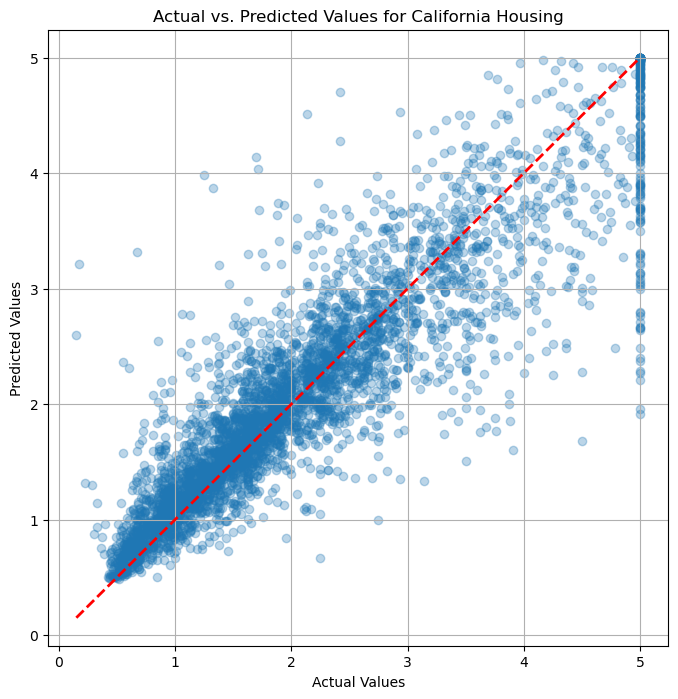

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    max_error
)

# 1. Load and split the data
# We'll use the California Housing dataset, a popular regression benchmark.
housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the model
# RandomForestRegressor is a powerful and commonly used model for regression tasks.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training RandomForestRegressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# --- REGRESSION METRICS ---

print("\n" + "="*30)
print("Regression Metrics")
print("="*30)

# 4. Mean Absolute Error (MAE)
# The average absolute difference between the predicted and actual values.
# It's in the same units as the target variable (e.g., thousands of dollars).
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.3f}")

# 5. Mean Squared Error (MSE)
# The average of the squared differences. It penalizes larger errors more heavily.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.3f}")

# 6. Root Mean Squared Error (RMSE)
# The square root of MSE. It's also in the same units as the target, making it more interpretable than MSE.
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

# 7. R-squared (R²) Score (Coefficient of Determination)
# Represents the proportion of the variance in the target that is predictable from the features.
# A score of 1.0 is a perfect prediction. A score of 0 means the model is no better than just predicting the mean.
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.3f}")

# 8. Median Absolute Error
# Similar to MAE but uses the median, making it robust to outliers.
medae = median_absolute_error(y_test, y_pred)
print(f"Median Absolute Error: {medae:.3f}")

# 9. Max Error
# The worst-case error between the predicted and true values.
max_err = max_error(y_test, y_pred)
print(f"Max Error: {max_err:.3f}")
print("-" * 30)


# --- VISUALIZATION ---

# A scatter plot of Actual vs. Predicted values is a great way to visualize performance.
# For a perfect model, all points would lie on the diagonal line.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
# Plot a diagonal line representing a perfect prediction (y_test = y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for California Housing')
plt.grid(True)
plt.show()

## Exercise
Try using cross-validation with a logistic regression and compare its performance.

In [ ]:
# Your code here

## Summary
- Validation techniques prevent overfitting and ensure model reliability.
- Different metrics are used depending on the problem type.


## Further Reading
- [Model Evaluation - scikit-learn](https://scikit-learn.org/stable/model_evaluation.html)
- [Classification Metrics](https://developers.google.com/machine-learning/crash-course/classification/precision-and-recall)
